# Loan Default Analysis

**Dataset:** Loan Default Prediction Dataset — from
[Kaggle](https://www.kaggle.com/datasets/nikhil1e9/loan-default) (255,347 loans, 18 features)

**Goal:** Answer a real lending business question - who defaults, what factors predict it, and what
happens financially if we tighten approval criteria? - using core pandas skills: `groupby`, `qcut`,
`pivot_table`, and `corr()`.

---


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/ispiermacbook/Downloads/loan_default.csv')
df.shape

(255347, 18)

## Step 0: Data Understanding & Quality Check

**Why this matters:** Before answering any business question, always confirm what the data actually
contains and whether it can be trusted - especially in finance, where a bad number can lead to a real
lending decision.


In [2]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Total missing values:', df.isnull().sum().sum())

Missing values per column:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Total missing values: 0


In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate Loan IDs:', df['LoanID'].duplicated().sum())

Duplicate rows: 0
Duplicate Loan IDs: 0


**Result:** 255,347 rows, 18 columns, **zero missing values**, **zero duplicate rows**, and every
`LoanID` is unique.

**Insight:** This is a clean, well-prepared dataset - no imputation or de-duplication needed before
starting analysis.

**Recommendation:** Always run these checks first, regardless of how well-documented a dataset
appears to be.

---


## Question 1: What is our overall loan default rate?

**Business problem:** Before anything else, the lending team needs one trustworthy baseline number - what
share of loans in our portfolio actually default?

Default
0    225694
1     29653
Name: count, dtype: int64

Default
0    88.4
1    11.6
Name: proportion, dtype: float64


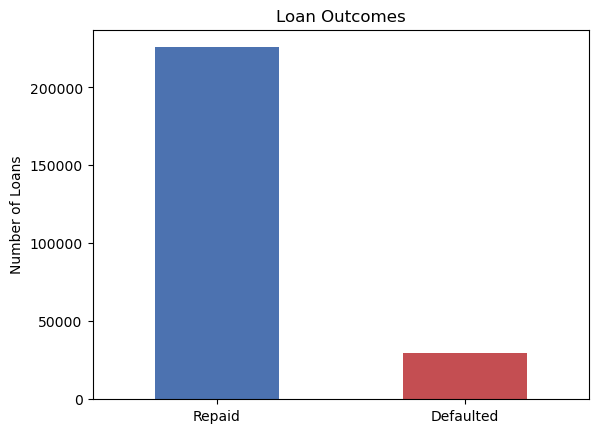

In [6]:
counts = df['Default'].value_counts()
pct = df['Default'].value_counts(normalize=True) * 100

print(counts)
print()
print(pct.round(1))

counts.index = ['Repaid', 'Defaulted']
counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Loan Outcomes')
plt.ylabel('Number of Loans')
plt.xticks(rotation=0)
plt.show()

**Result:** 29,653 of 255,347 loans defaulted -> **11.6% default rate**.

**Insight:** Overall default rate is 11.6%, but we need to analyze segments to find the main risk drivers.

**Recommendation:** Track default rate by segment to identify high-risk groups.

---


## Question 2: Which employment types and loan purposes default the most?

**Business problem:** Identify which borrower segments have the highest default risk.

**Concept:** `groupby()` splitting the data by category and comparing default rate within each
group.


In [7]:
def default_rate(data, group_col):
    rate = data.groupby(group_col, observed=True)['Default'].mean().mul(100).round(1)
    count = data.groupby(group_col, observed=True)['Default'].count()
    return pd.DataFrame({'DefaultRate_%': rate, 'LoanCount': count}).sort_values('DefaultRate_%', ascending=False)

employment_rate = default_rate(df, 'EmploymentType')
purpose_rate = default_rate(df, 'LoanPurpose')
education_rate = default_rate(df, 'Education')

print('--- By Employment Type ---')
print(employment_rate)
print('\n--- By Loan Purpose ---')
print(purpose_rate)
print('\n--- By Education ---')
print(education_rate)

--- By Employment Type ---
                DefaultRate_%  LoanCount
EmploymentType                          
Unemployed               13.6      63824
Part-time                12.0      64161
Self-employed            11.5      63706
Full-time                 9.5      63656

--- By Loan Purpose ---
             DefaultRate_%  LoanCount
LoanPurpose                          
Business              12.3      51298
Auto                  11.9      50844
Education             11.8      51005
Other                 11.8      50914
Home                  10.2      51286

--- By Education ---
             DefaultRate_%  LoanCount
Education                            
High School           12.9      63903
Bachelor's            12.1      64366
Master's              10.9      63541
PhD                   10.6      63537


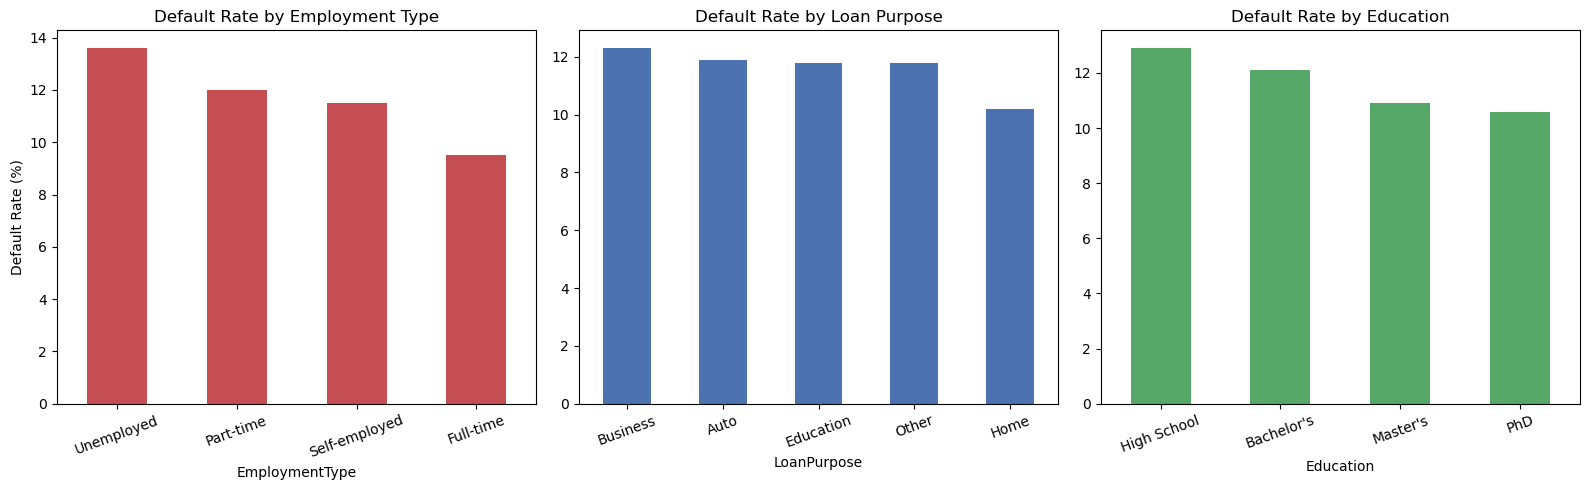

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

employment_rate['DefaultRate_%'].plot(kind='bar', ax=axes[0], color='#C44E52')
axes[0].set_title('Default Rate by Employment Type')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=20)

purpose_rate['DefaultRate_%'].plot(kind='bar', ax=axes[1], color='#4C72B0')
axes[1].set_title('Default Rate by Loan Purpose')
axes[1].tick_params(axis='x', rotation=20)

education_rate['DefaultRate_%'].plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Default Rate by Education')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Result:** **Unemployed borrowers default at 13.6%**, the highest of any employment type, vs. **9.5%**
for Full-time employees. By loan purpose, **Business loans default the most (12.3%)** and **Home loans the
least (10.2%)**. By education, default rate declines steadily from **High School (12.9%)** to **PhD
(10.6%)**.

**Insight:** Employment type shows the largest difference in default risk.

**Recommendation:** Give more attention to employment stability and Business-purpose loans.

---


## Question 3: Does credit score or debt-to-income ratio predict default?

**Business problem:** Check whether Credit Score and DTI Ratio are related to default risk.

**Concept:** `pd.qcut()` splitting `CreditScore` and `DTIRatio` into 4 equal groups (quartiles) and compare their default rates.


In [9]:
df['CreditScoreBand'] = pd.qcut(df['CreditScore'], 4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
df['DTIBand'] = pd.qcut(df['DTIRatio'], 4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

credit_rate = default_rate(df, 'CreditScoreBand')
dti_rate = default_rate(df, 'DTIBand')

print('--- By Credit Score Quartile ---')
print(credit_rate)
print('\n--- By DTI Ratio Quartile ---')
print(dti_rate)

--- By Credit Score Quartile ---
                 DefaultRate_%  LoanCount
CreditScoreBand                          
Q1 (Lowest)               13.1      64140
Q2                        11.9      63803
Q3                        11.3      63896
Q4 (Highest)              10.2      63508

--- By DTI Ratio Quartile ---
              DefaultRate_%  LoanCount
DTIBand                               
Q4 (Highest)           12.3      62348
Q3                     12.0      63781
Q2                     11.5      63970
Q1 (Lowest)            10.7      65248


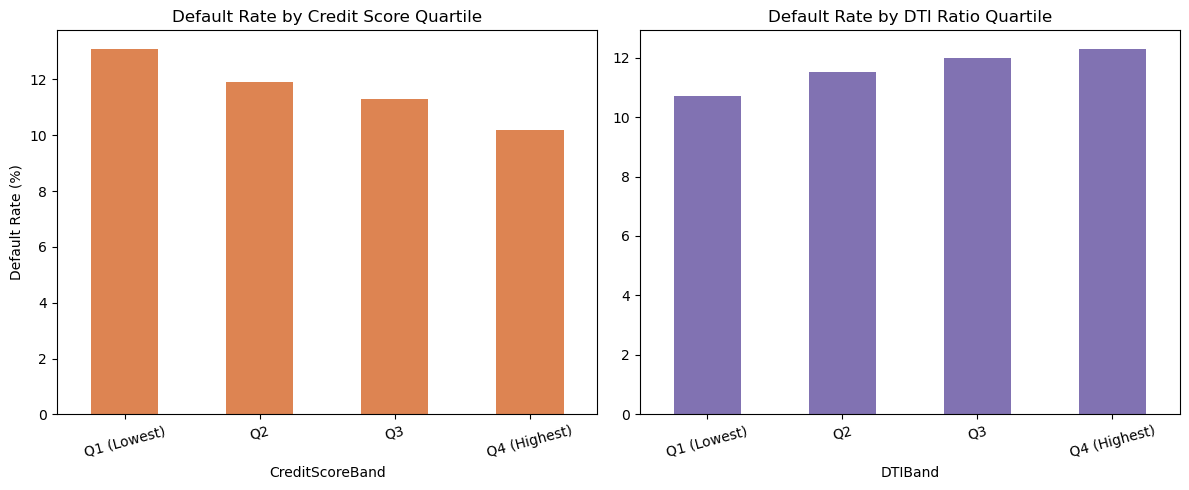

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

band_order = ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
credit_rate.loc[band_order]['DefaultRate_%'].plot(kind='bar', ax=axes[0], color='#DD8452')
axes[0].set_title('Default Rate by Credit Score Quartile')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

dti_rate.loc[band_order]['DefaultRate_%'].plot(kind='bar', ax=axes[1], color='#8172B2')
axes[1].set_title('Default Rate by DTI Ratio Quartile')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Result:** Default rate declines from **13.1% (lowest credit score quartile) to 10.2% (highest)**, and DTI default rate rises from **10.7% (lowest DTI) to
12.3% (highest DTI)**.

**Insight:** Both show the expected relationship, but the differences are relatively small.

**Recommendation:** Use credit score and DTI along with other factors, rather than relying on either alone.

---


## Question 4: What factors correlate most with default?

**Business problem:** Identify which numerical factors are most strongly related to default risk.

**Concept:** Use `corr()` to measure the relationship between each numeric variable and `Default` (already 0/1, so no encoding needed this time).


In [11]:
numeric_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
                 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']

corr_matrix = df[numeric_cols].corr()
default_corr = corr_matrix['Default'].drop('Default').sort_values()
print(default_corr.round(3))

Age              -0.168
Income           -0.099
MonthsEmployed   -0.097
CreditScore      -0.034
LoanTerm          0.001
DTIRatio          0.019
NumCreditLines    0.028
LoanAmount        0.087
InterestRate      0.131
Name: Default, dtype: float64


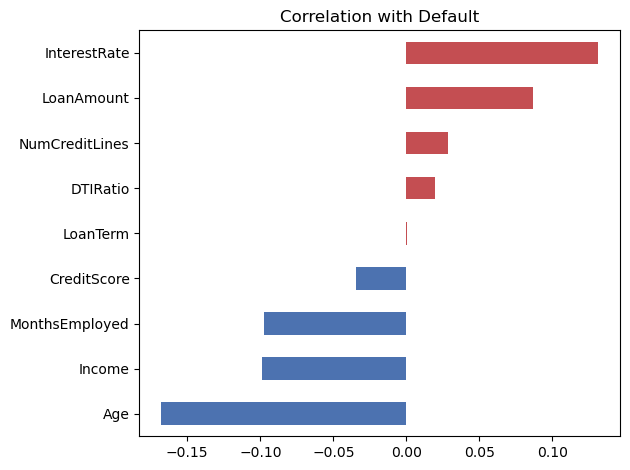

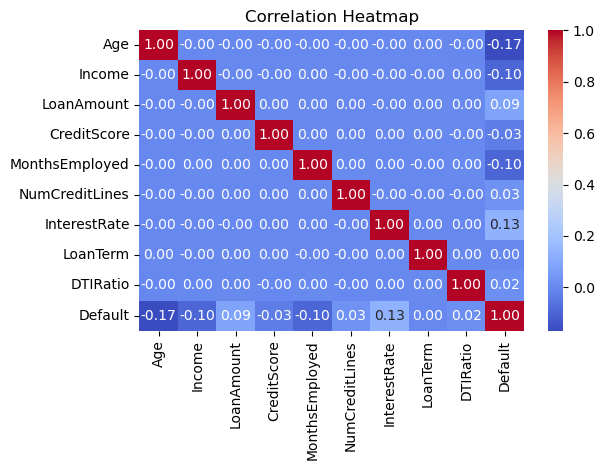

In [12]:
default_corr.plot(kind='barh', color=['#C44E52' if v > 0 else '#4C72B0' for v in default_corr])
plt.title('Correlation with Default')
plt.tight_layout()
plt.show()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Result:** **Age (-0.17)** is the strongest correlate - younger borrowers default more. **InterestRate
(+0.13)** is the strongest positive correlate. Income
(-0.10) and MonthsEmployed (-0.10) show modest negative correlation. **CreditScore, notably, shows a very
weak correlation (-0.03)**

**Insight:** Correlation alone may miss patterns, so grouped analysis is also important.

**Recommendation:** Consider multiple factors together rather than relying on Credit Score alone.

---


## Question 5: Where do credit score and DTI ratio combine to create the highest risk?

**Business problem:** Find combinations of low credit score and high DTI where default risk is highest.

**Concept:** `pivot_table()` to compare default rates across Credit Score quartiles and DTI quartiles together.


In [13]:
pivot = pd.pivot_table(
    df,
    values='Default',
    index='CreditScoreBand',
    columns='DTIBand',
    aggfunc='mean',
    observed=True
) * 100
pivot = pivot.round(1)

print('Default rate (%) by Credit Score Quartile x DTI Quartile:')
print(pivot)

Default rate (%) by Credit Score Quartile x DTI Quartile:
DTIBand          Q1 (Lowest)    Q2    Q3  Q4 (Highest)
CreditScoreBand                                       
Q1 (Lowest)             12.0  13.1  13.5          13.6
Q2                      11.2  11.8  11.9          12.7
Q3                      10.4  11.0  12.0          11.8
Q4 (Highest)             9.0  10.2  10.6          11.1


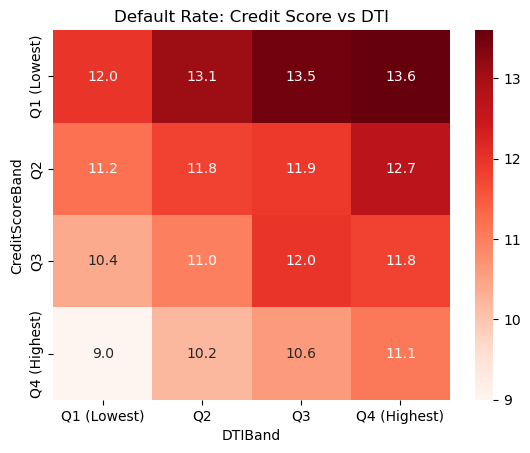

In [14]:
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds')
plt.title('Default Rate: Credit Score vs DTI')
plt.show()

**Result:** The highest-risk group is **lowest credit score + highest DTI, at 13.6%** , while the lowest-risk group is (**highest credit score + lowest DTI, at 9.0%**). The gradient across the grid is
smooth and consistent in both directions.

**Insight:** Combining both factors gives a stronger risk signal than using either one alone.

**Recommendation:** Use credit score + DTI combinations to create risk tiers.

---


## Question 6: If we tighten approval criteria, what's the financial trade-off?

**Business problem:** Measure whether rejecting high-risk loans saves more money from defaults than the interest revenue lost from good borrowers.

**Concept:** Apply a risk-based business rule and compare:
    
- **Avoided Loss** = Principal of risky defaulted loans rejected
- **Lost Revenue** = Interest from good loans rejected

*Assumption:* A default means 100% loss of principal, with no recovery.


In [15]:
# Business rule: highest-risk segment identified in Q5 - lowest credit quartile AND highest DTI quartile
high_risk = df[(df['CreditScoreBand'] == 'Q1 (Lowest)') & (df['DTIBand'] == 'Q4 (Highest)')].copy()

print("Total loans:", len(df))
print("High-risk loans:", len(high_risk))
print("High-risk default rate:", round(high_risk['Default'].mean()*100, 1), "%")
print("Overall default rate:", round(df['Default'].mean()*100, 1), "%")

Total loans: 255347
High-risk loans: 15671
High-risk default rate: 13.6 %
Overall default rate: 11.6 %


Foregone revenue: 221126215
Avoided losses: 305316836
Net impact: 84190621


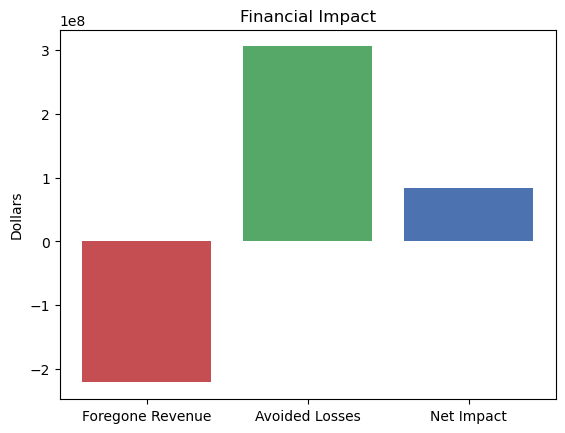

In [16]:
good = high_risk[high_risk['Default'] == 0]
bad = high_risk[high_risk['Default'] == 1]

foregone = (good['LoanAmount'] * good['InterestRate'] / 100).sum()
avoided = bad['LoanAmount'].sum()

print("Foregone revenue:", round(foregone))
print("Avoided losses:", round(avoided))
print("Net impact:", round(avoided - foregone))

plt.bar(
    ['Foregone Revenue', 'Avoided Losses', 'Net Impact'],
    [ -foregone, avoided, avoided - foregone],
    color=['#C44E52', '#55A868', '#4C72B0']
)
plt.ylabel('Dollars')
plt.title('Financial Impact')
plt.show()

**Result:** Rejecting the high-risk segment would lose **$221.1M** in interest revenue from good loans, but avoid **$305.3M** in default losses, giving a **net positive of $84.2M**.

**Insight:** Default losses are much larger than the interest earned, so even a modestly higher default rate can have a significant financial impact.

**Recommendation:** Focus stricter approval criteria on the low-credit-score + high-DTI segment rather than rejecting a broader group.

---


## Executive Summary

| # | Question | Key Finding |
|---|----------|-------------|
| 0 | Data quality | 255,347 rows, 18 columns, zero missing values, zero duplicates |
| 1 | Overall default rate | 11.6% (29,653 / 255,347 loans) |
| 2 | Employment & purpose breakdown | Unemployed borrowers default most (13.6%); Business-purpose loans riskiest (12.3%) |
| 3 | Credit score & DTI | Both show the expected direction, but modest individual effect (~2-3 point spread each) |
| 4 | Correlation scan | Age is the strongest linear correlate; CreditScore's correlation is surprisingly weak despite a real quartile-level pattern |
| 5 | Combined risk (pivot) | Credit Score x DTI together produce a ~4.6 point spread - stronger than either factor alone |
| 6 | Recommended action | Tightening approval for the combined highest-risk segment nets an estimated +$84.2M (avoided losses outweigh foregone revenue) |

>I analyzed 255K loans and found that Credit Score and DTI have modest individual effects but become a stronger risk signal when combined. >I then quantified the financial trade-off of stricter approval criteria, estimating an $84M net benefit from targeting the highest-risk >segment.